<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  9.10MB/s    in 17s     
2026-09-15 09:03:30 (9.11 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [23]:
!pip install numpy
import numpy as np

In [10]:
!pip install seaborn
import seaborn as sns

In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 164.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 180.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 180.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 173.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 165.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [2]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [3]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [4]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [5]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [6]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [11]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


We use log10 transform as our data is very spread out due to the CompTotal column being in the native reported currency and not normalizwd.

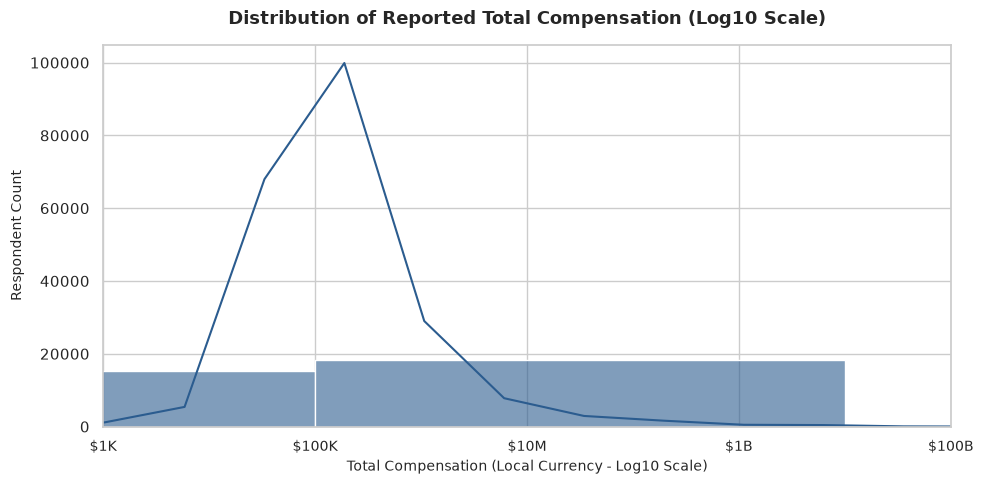

In [24]:
sns.set_theme(style="whitegrid", font="sans-serif")

query = """
SELECT CompTotal 
FROM main 
WHERE CompTotal IS NOT NULL 
  AND CompTotal > 0
"""
comp_total = pd.read_sql_query(query, conn)

log_vals = np.log10(comp_total["CompTotal"].dropna())

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    log_vals,
    kde=True,
    color="#2b5c8f",
    bins=30,
    edgecolor="white",
    alpha=0.6,
    ax=ax,
)

ax.set_xlim(3, 11)

fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]
ax.minorticks_off()
ax.set_xticks(fixed_ticks)
ax.set_xticklabels(fixed_labels, fontsize=10, fontweight="normal")

plt.title(
    "Distribution of Reported Total Compensation (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Compensation (Local Currency - Log10 Scale)", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)

plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.


We create a dictionary mapping categorical age brackets to their numeric midpoint values, convert the Age column to float, and plot a single horizontal Seaborn boxplot showing the median, IQR, and range of developer ages.

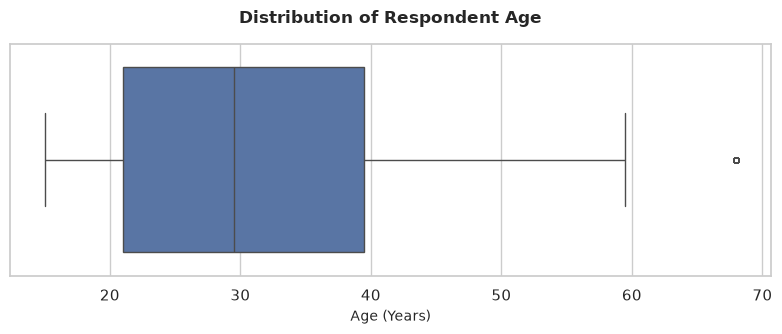

In [27]:
## Write your code here
query = '''
SELECT Age
FROM main
'''
df_age = pd.read_sql_query(query, conn)
age_numeric_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}

df_age["Age_Numeric"] = df_age["Age"].map(age_numeric_map)

# 3. Plot single horizontal boxplot of Age
plt.figure(figsize=(8, 3.5))

sns.boxplot(
    data=df_age,
    x="Age_Numeric",
    color="#4c72b0",
    flierprops=dict(marker="o", color="red", alpha=0.3, markersize=4),
)

plt.title(
    "Distribution of Respondent Age",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age (Years)", fontsize=10)

plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


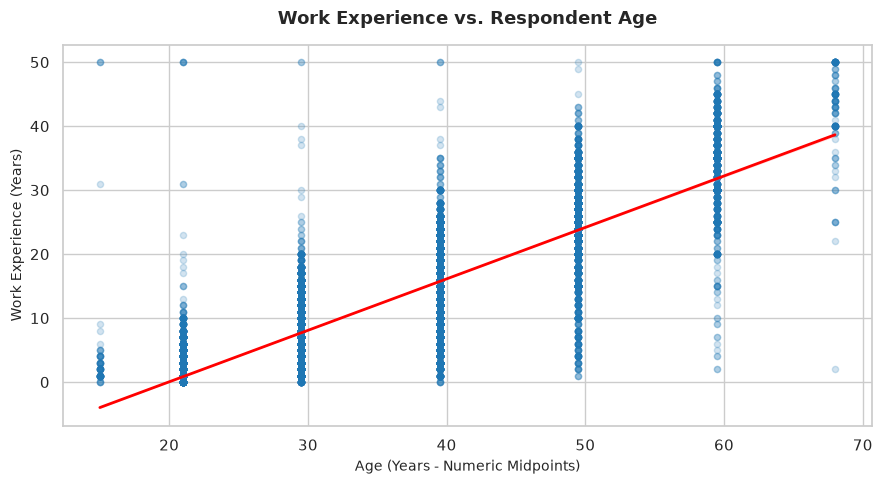

In [28]:
## Write your code here
query = '''
SELECT Age, WorkExp
FROM main
WHERE Age IS NOT NULL 
  AND Age != 'Prefer not to say'
  AND WorkExp IS NOT NULL'''
df_scatter = pd.read_sql_query(query, conn)

age_numeric_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_scatter["Age_Numeric"] = df_scatter["Age"].map(age_numeric_map)

plt.figure(figsize=(9, 5))

sns.regplot(
    data=df_scatter,
    x="Age_Numeric",
    y="WorkExp",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)

plt.title(
    "Work Experience vs. Respondent Age",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age (Years - Numeric Midpoints)", fontsize=10)
plt.ylabel("Work Experience (Years)", fontsize=10)

plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [36]:
query = """
SELECT TimeSearching, Frustration, Age 
FROM main 
WHERE TimeSearching IS NOT NULL 
  AND Frustration IS NOT NULL 
  AND Age IS NOT NULL 
  AND Age != 'Prefer not to say'
"""
df_bubble = pd.read_sql_query(query, conn)
df_bubble

,TimeSearching,Frustration,Age
0,30-60 minutes a day,Amount of technical debt;Number of software to...,35-44 years old
1,30-60 minutes a day,Amount of technical debt;Complexity of tech st...,35-44 years old
2,60-120 minutes a day,Amount of technical debt;Complexity of tech st...,45-54 years old
3,15-30 minutes a day,Amount of technical debt;Tracking my work;Comp...,25-34 years old
4,Less than 15 minutes a day,Number of software tools in use;Tracking my wo...,25-34 years old
...,...,...,...
28033,60-120 minutes a day,Amount of technical debt;Showing my contributi...,25-34 years old
28034,60-120 minutes a day,Tracking my work;Complexity of tech stack for ...,18-24 years old
28035,Less than 15 minutes a day,None of these,25-34 years old
28036,15-30 minutes a day,Complexity of tech stack for deployment;Comple...,25-34 years old


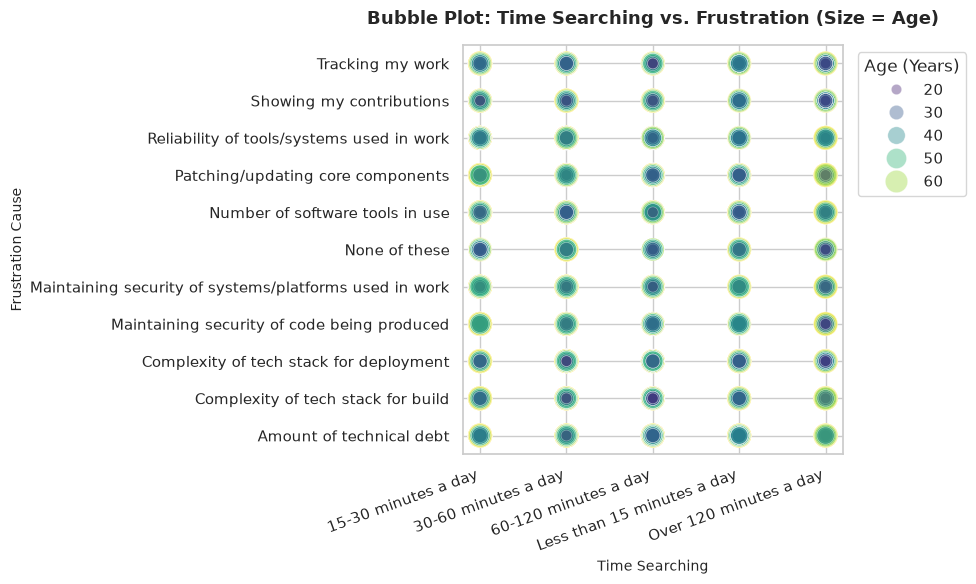

In [37]:
query = """
SELECT TimeSearching, Frustration, Age 
FROM main 
WHERE TimeSearching IS NOT NULL 
  AND Frustration IS NOT NULL 
  AND Age IS NOT NULL 
  AND Age != 'Prefer not to say'
"""
df_bubble = pd.read_sql_query(query, conn)

age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_bubble["Age_Numeric"] = df_bubble["Age"].map(age_map)

df_bubble["Frustration"] = df_bubble["Frustration"].str.split(";")
df_bubble = df_bubble.explode("Frustration")
df_bubble["Frustration"] = df_bubble["Frustration"].str.strip()

time_categories = sorted(df_bubble["TimeSearching"].dropna().unique())
frust_categories = sorted(df_bubble["Frustration"].dropna().unique())

time_map = {cat: i for i, cat in enumerate(time_categories)}
frust_map = {cat: i for i, cat in enumerate(frust_categories)}

df_bubble["Time_Code"] = df_bubble["TimeSearching"].map(time_map)
df_bubble["Frust_Code"] = df_bubble["Frustration"].map(frust_map)

df_clean = df_bubble.dropna(
    subset=["Time_Code", "Frust_Code", "Age_Numeric"]
).copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Time_Code",
    y="Frust_Code",
    size="Age_Numeric",
    sizes=(30, 300),
    hue="Age_Numeric",
    palette="viridis",
    alpha=0.4,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_xticks(range(len(time_categories)))
ax.set_xticklabels(time_categories, rotation=20, ha="right")

ax.set_yticks(range(len(frust_categories)))
ax.set_yticklabels(frust_categories)

plt.title(
    "Bubble Plot: Time Searching vs. Frustration (Size = Age)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Time Searching", fontsize=10)
plt.ylabel("Frustration Cause", fontsize=10)
plt.legend(
    title="Age (Years)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

Let's try adding some jitter to the points.

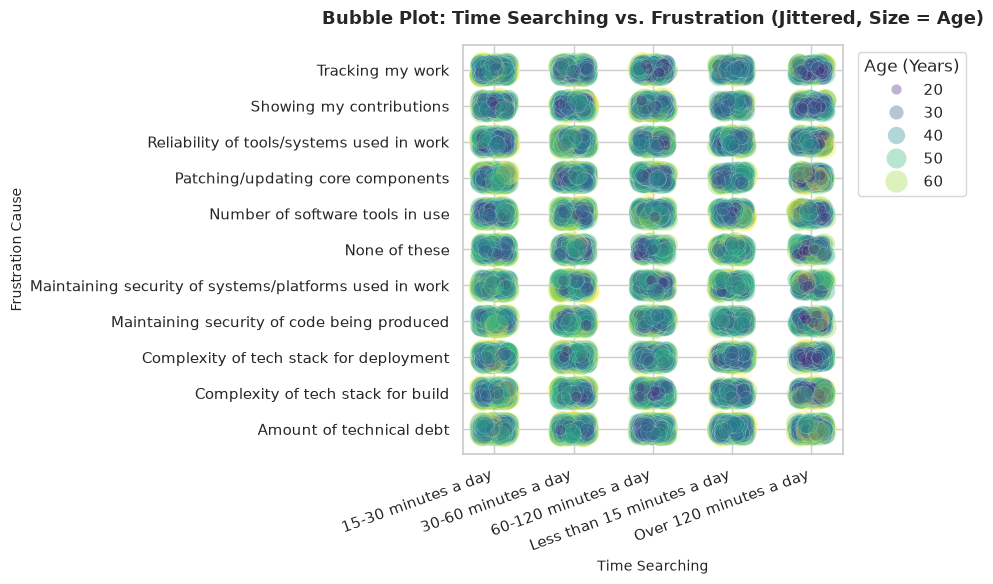

In [38]:
# Query dataset for relevant search, frustration, and age variables
query = """
SELECT TimeSearching, Frustration, Age 
FROM main 
WHERE TimeSearching IS NOT NULL 
  AND Frustration IS NOT NULL 
  AND Age IS NOT NULL 
  AND Age != 'Prefer not to say'
"""
df_bubble = pd.read_sql_query(query, conn)

# Map age ranges to numeric midpoints to drive bubble sizes
age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_bubble["Age_Numeric"] = df_bubble["Age"].map(age_map)

# Expand multi-selection frustration entries into distinct rows
df_bubble["Frustration"] = df_bubble["Frustration"].str.split(";")
df_bubble = df_bubble.explode("Frustration")
df_bubble["Frustration"] = df_bubble["Frustration"].str.strip()

# Map unique text categories to integer indices for coordinate plotting
time_categories = sorted(df_bubble["TimeSearching"].dropna().unique())
frust_categories = sorted(df_bubble["Frustration"].dropna().unique())

time_map = {cat: i for i, cat in enumerate(time_categories)}
frust_map = {cat: i for i, cat in enumerate(frust_categories)}

df_bubble["Time_Code"] = df_bubble["TimeSearching"].map(time_map)
df_bubble["Frust_Code"] = df_bubble["Frustration"].map(frust_map)

# Drop any unmapped or missing rows
df_clean = df_bubble.dropna(
    subset=["Time_Code", "Frust_Code", "Age_Numeric"]
).copy()

# Add random offset jitter to resolve point overlap on discrete categories
np.random.seed(42)
df_clean["X_jitter"] = df_clean["Time_Code"] + np.random.uniform(
    -0.18, 0.18, size=len(df_clean)
)
df_clean["Y_jitter"] = df_clean["Frust_Code"] + np.random.uniform(
    -0.18, 0.18, size=len(df_clean)
)

# Initialize plot figure
fig, ax = plt.subplots(figsize=(10, 6))

# Render bubble chart using jittered positions and age-scaled markers
sns.scatterplot(
    data=df_clean,
    x="X_jitter",
    y="Y_jitter",
    size="Age_Numeric",
    sizes=(30, 300),
    hue="Age_Numeric",
    palette="viridis",
    alpha=0.35,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
)

# Restore categorical text labels on axes
ax.set_xticks(range(len(time_categories)))
ax.set_xticklabels(time_categories, rotation=20, ha="right")

ax.set_yticks(range(len(frust_categories)))
ax.set_yticklabels(frust_categories)

# Apply titles, axis formatting, and external legend positioning
plt.title(
    "Bubble Plot: Time Searching vs. Frustration (Jittered, Size = Age)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Time Searching", fontsize=10)
plt.ylabel("Frustration Cause", fontsize=10)
plt.legend(
    title="Age (Years)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


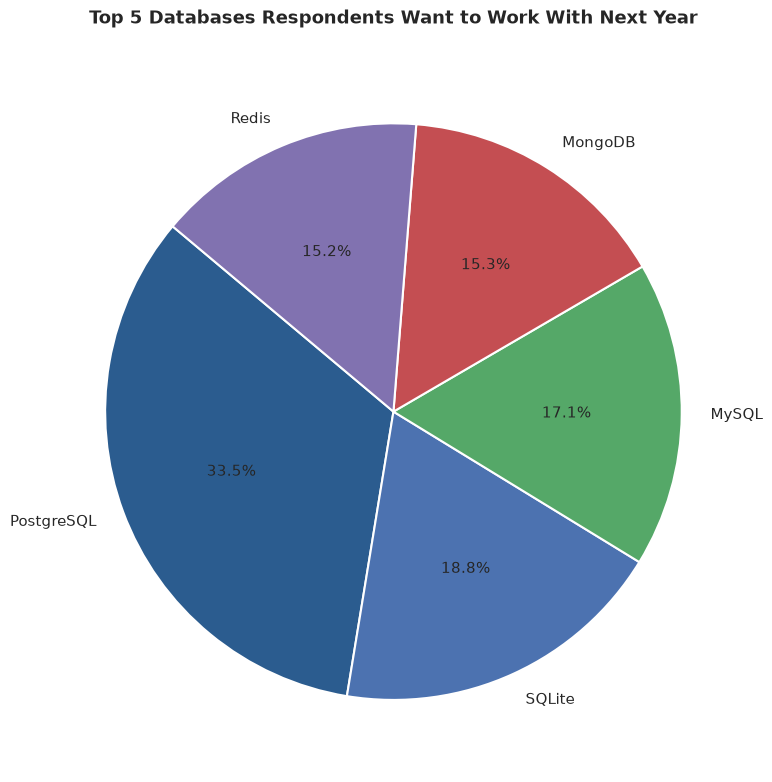

In [39]:
# Query DatabaseWantToWorkWith from the SQLite database
query = """
SELECT DatabaseWantToWorkWith 
FROM main 
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
df_db = pd.read_sql_query(query, conn)

# Split semi-colon delimited survey responses and count occurrences
df_db_exploded = df_db["DatabaseWantToWorkWith"].str.split(";").explode()
df_db_exploded = df_db_exploded.str.strip()

# Extract top 5 databases
top_5_db = df_db_exploded.value_counts().head(5)

# Plot Pie Chart
plt.figure(figsize=(8, 8))
colors = ["#2b5c8f", "#4c72b0", "#55a868", "#c44e52", "#8172b0"]

plt.pie(
    top_5_db,
    labels=top_5_db.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11},
)

plt.title(
    "Top 5 Databases Respondents Want to Work With Next Year",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


In [42]:
# Query TimeSearching, TimeAnswering, and Age
query = """
SELECT TimeSearching, TimeAnswering, Age 
FROM main 
WHERE Age = '25-34 years old'
  AND TimeSearching IS NOT NULL 
  AND TimeAnswering IS NOT NULL
"""
df_stacked = pd.read_sql_query(query, conn)
df_stacked.head()

,TimeSearching,TimeAnswering,Age
0,15-30 minutes a day,30-60 minutes a day,25-34 years old
1,Less than 15 minutes a day,15-30 minutes a day,25-34 years old
2,60-120 minutes a day,15-30 minutes a day,25-34 years old
3,60-120 minutes a day,15-30 minutes a day,25-34 years old
4,30-60 minutes a day,15-30 minutes a day,25-34 years old


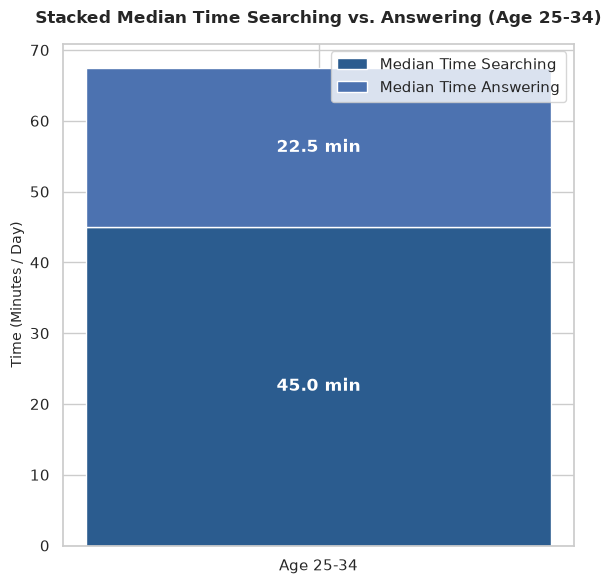

In [43]:
# Query target age bracket
query = """
SELECT TimeSearching, TimeAnswering, Age 
FROM main 
WHERE Age = '25-34 years old'
  AND TimeSearching IS NOT NULL 
  AND TimeAnswering IS NOT NULL
"""
df_stacked = pd.read_sql_query(query, conn)

# Map string categories to numeric minute midpoints
time_map = {
    "Less than 15 minutes a day": 7.5,
    "15-30 minutes a day": 22.5,
    "30-60 minutes a day": 45.0,
    "60-120 minutes a day": 90.0,
    "Over 120 minutes a day": 150.0,
}

df_stacked["Searching_Mins"] = df_stacked["TimeSearching"].map(time_map)
df_stacked["Answering_Mins"] = df_stacked["TimeAnswering"].map(time_map)

# Compute medians in minutes
median_search = df_stacked["Searching_Mins"].median()
median_answer = df_stacked["Answering_Mins"].median()

# Render stacked bar plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.bar(
    ["Age 25-34"],
    [median_search],
    label="Median Time Searching",
    color="#2b5c8f",
    width=0.4,
)

ax.bar(
    ["Age 25-34"],
    [median_answer],
    bottom=[median_search],
    label="Median Time Answering",
    color="#4c72b0",
    width=0.4,
)

# Annotate values inside stacked segments
ax.text(
    0,
    median_search / 2,
    f"{median_search:.1f} min",
    ha="center",
    va="center",
    color="white",
    fontweight="bold",
)
ax.text(
    0,
    median_search + (median_answer / 2),
    f"{median_answer:.1f} min",
    ha="center",
    va="center",
    color="white",
    fontweight="bold",
)

plt.title(
    "Stacked Median Time Searching vs. Answering (Age 25-34)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.ylabel("Time (Minutes / Day)", fontsize=10)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


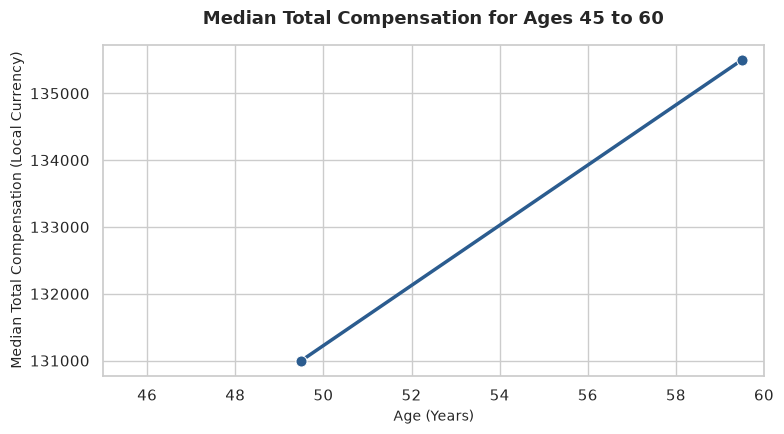

In [47]:
## Write your code 
# Query Age and CompTotal for developer age groups spanning 45 to 60
query = """
SELECT Age, CompTotal 
FROM main 
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL 
  AND CompTotal > 0
"""
df_line = pd.read_sql_query(query, conn)

# Map age ranges to numeric midpoints
age_map = {
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
}
df_line["Age_Numeric"] = df_line["Age"].map(age_map)

# Compute median total compensation by numeric age
df_medians = (
    df_line.groupby("Age_Numeric")["CompTotal"]
    .median()
    .reset_index()
    .sort_values("Age_Numeric")
)

# Plot line chart
plt.figure(figsize=(8, 4.5))

sns.lineplot(
    data=df_medians,
    x="Age_Numeric",
    y="CompTotal",
    marker="o",
    color="#2b5c8f",
    linewidth=2.5,
    markersize=8,
)

plt.title(
    "Median Total Compensation for Ages 45 to 60",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age (Years)", fontsize=10)
plt.ylabel("Median Total Compensation (Local Currency)", fontsize=10)
plt.xlim(45, 60)

plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


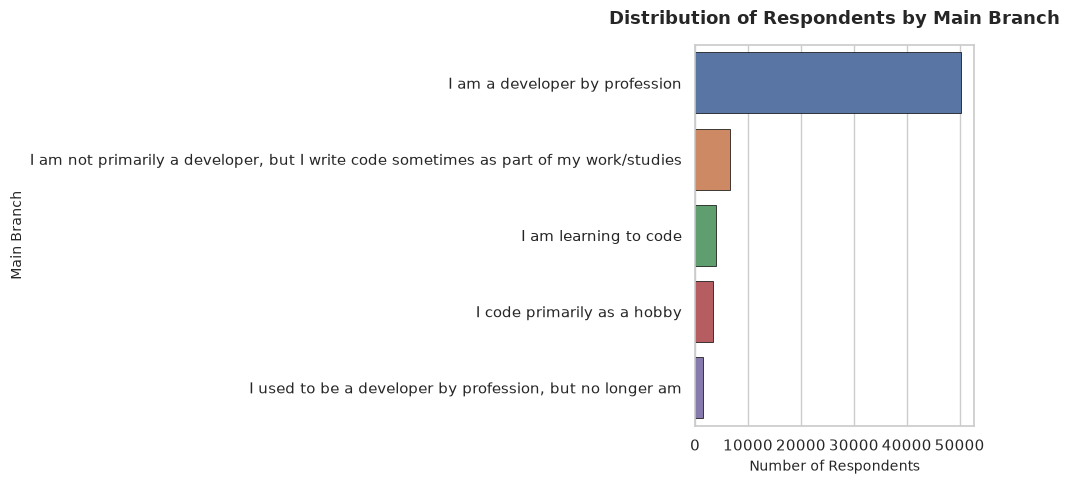

In [46]:
## Write your code here
# Query MainBranch column
query = """
SELECT MainBranch 
FROM main 
WHERE MainBranch IS NOT NULL
"""
df_branch = pd.read_sql_query(query, conn)

# Count occurrences for each branch
branch_counts = df_branch["MainBranch"].value_counts().reset_index()
branch_counts.columns = ["MainBranch", "Count"]

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 5))

sns.barplot(
    data=branch_counts,
    y="MainBranch",
    x="Count",
    hue="MainBranch",
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "Distribution of Respondents by Main Branch",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Respondents", fontsize=10)
plt.ylabel("Main Branch", fontsize=10)

plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
